In [76]:
# IMPORT LIBRARIES

In [77]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported successfully")

Libraries imported successfully


In [78]:
# LOAD DATASET

In [79]:
df = pd.read_csv(r"used_cars_dataset.csv")
print("Original Shape: ", df.shape)

Original Shape:  (9582, 12)


In [80]:
print("Missing Values")

missing_before_cleaning = df.isnull().sum()
print(missing_before_cleaning[missing_before_cleaning > 0])

Missing Values
kmDriven    47
dtype: int64


In [81]:
# HANDLE MISSING VALUES

In [82]:
# FILL KmDRIVEN with mediam (better for skewed data)

In [83]:
median_km = df['kmDriven'].median()
df['kmDriven'] = df['kmDriven'].fillna(median_km)
print(f"✅ Filled kmDriven with median : {median_km:,.0f} km")

✅ Filled kmDriven with median : 65,000 km


In [84]:
df['AdditionInfo'] = df['AdditionInfo'].fillna('No Info')
print("✅ Filled AdditionalInfo with 'No Info'")

✅ Filled AdditionalInfo with 'No Info'


In [85]:
# Verify no missing values remain

In [86]:
print("\nMissing values after filling:")
print(df.isnull().sum())


Missing values after filling:
Unnamed: 0      0
Brand           0
model           0
Year            0
Age             0
kmDriven        0
Transmission    0
Owner           0
FuelType        0
PostedDate      0
AdditionInfo    0
AskPrice        0
dtype: int64


In [87]:
# OUTLIER DETECTION FOR ASKPRICE

In [88]:
print("OUTLIER DETECTION")

q1 = df['AskPrice'].quantile(0.25)
q3 = df['AskPrice'].quantile(0.75)
IQR = q3 - q1
lower_bound = q1 - 1.5*IQR
upper_bound = q3 + 1.5*IQR

print(f"Q1 (25th percentile): ₹{q1:,.0f}")
print(f"Q3 (75th percentile): ₹{q3:,.0f}")
print(f"IQR: ₹{IQR:,.0f}")
print(f"Lower bound: ₹{lower_bound:,.0f}")
print(f"Upper bound: ₹{upper_bound:,.0f}")

outliers = df[(df['AskPrice'] < lower_bound) | (df['AskPrice'] > upper_bound)]
print(f"\nOutliers found: {len(outliers)} ({len(outliers)/len(df)*100:.1f}%)")

OUTLIER DETECTION
Q1 (25th percentile): ₹361,000
Q3 (75th percentile): ₹1,125,000
IQR: ₹764,000
Lower bound: ₹-785,000
Upper bound: ₹2,271,000

Outliers found: 895 (9.3%)


In [89]:
# Visualize before and after outlier removal

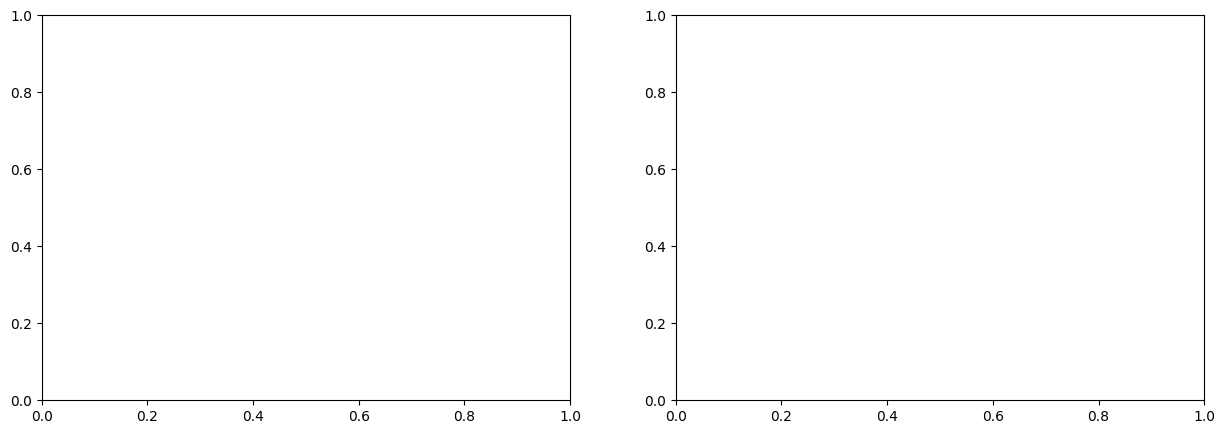

In [90]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

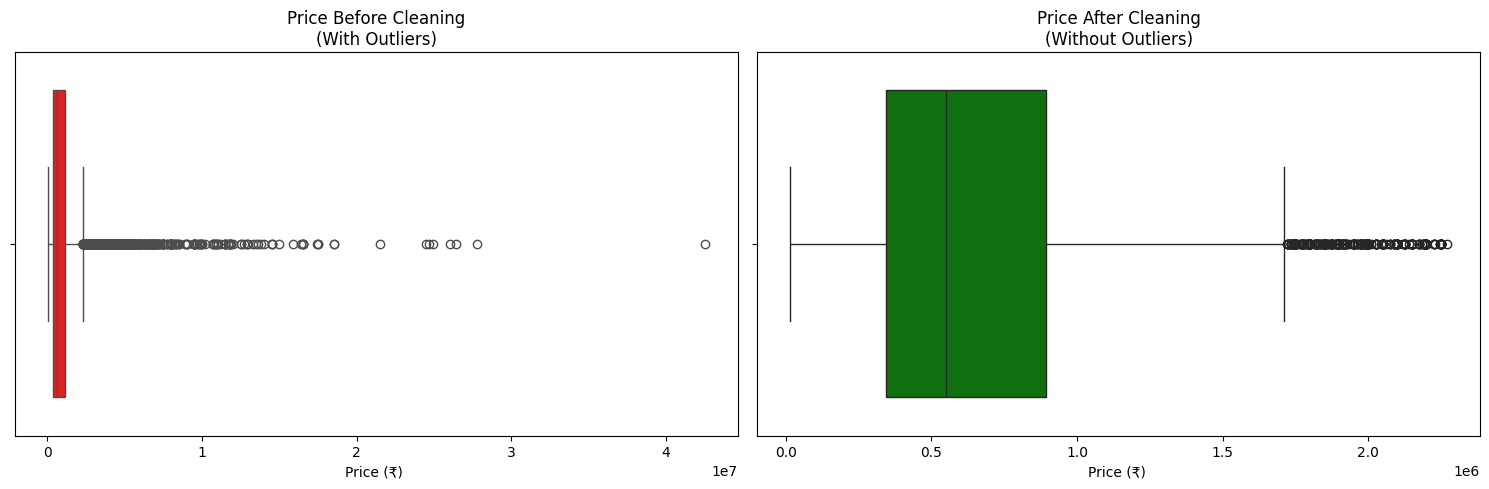


Rows removed: 895


In [91]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.boxplot(x = df['AskPrice'], ax=axes[0], color='red')
axes[0].set_title(f'Price Before Cleaning\n(With Outliers)')
axes[0].set_xlabel('Price (₹) ')

df_clean = df[(df['AskPrice'] >= lower_bound) & (df['AskPrice'] <= upper_bound)]

sns.boxplot(x = df_clean['AskPrice'], ax=axes[1], color='green')
axes[1].set_title(f'Price After Cleaning\n(Without Outliers)')
axes[1].set_xlabel('Price (₹) ')

plt.tight_layout()
plt.show()

print(f"\nRows removed: {len(df) - len(df_clean)}")

In [92]:
# REMOVE DUPLICATES

In [93]:
duplicates = df_clean.duplicated().sum()
print(f"Duplicates found: {duplicates}")

if duplicates > 0:
    df_clean = df_clean.drop_duplicates()
    print(f"✅ Removed {duplicates} duplicate rows")

Duplicates found: 0


In [94]:
# Convert PostedDate to datetime

In [95]:
# IMPORTANT: Apply this to your ORIGINAL dataframe, NOT df_clean
# If your original dataframe is named 'df', do this:

# 1. Strip the whitespace (fixes the "Nov-24 " problem)
df_clean['PostedDate'] = df_clean['PostedDate'].str.strip()

# 2. NOW convert it with the correct format
df_clean['PostedDate'] = pd.to_datetime(df_clean['PostedDate'], 
                                  format='%b-%y', 
                                  errors='coerce')

print(f"Date range: {df_clean['PostedDate'].min()} to {df_clean['PostedDate'].max()}")

Date range: 2023-12-01 00:00:00 to 2024-11-01 00:00:00


In [96]:
# Final cleaning summary

In [97]:
print("CLEANING SUMMARY")
print(f"Original shape: {df.shape}")
print(f"Cleaned shape: {df_clean.shape}")
print(f"Total rows removed: {df.shape[0] - df_clean.shape[0]}")
print(f"Missing values remaining: {df_clean.isnull().sum().sum()}")
print(f"Duplicate rows removed: {duplicates}")
print(f"Outliers removed: {len(outliers)}")

CLEANING SUMMARY
Original shape: (9582, 12)
Cleaned shape: (8687, 12)
Total rows removed: 895
Missing values remaining: 0
Duplicate rows removed: 0
Outliers removed: 895


In [98]:
# Save cleaned data

In [99]:
df_clean.to_csv('cleaned_cars.csv', index=False)
print("✅ Cleaned data saved as 'cleaned_cars.csv'")

✅ Cleaned data saved as 'cleaned_cars.csv'


In [100]:
# Show final data info

In [101]:
print("\nFinal Data Info:")
df_clean.info()


Final Data Info:
<class 'pandas.DataFrame'>
Index: 8687 entries, 0 to 9581
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   Unnamed: 0    8687 non-null   int64         
 1   Brand         8687 non-null   str           
 2   model         8687 non-null   str           
 3   Year          8687 non-null   int64         
 4   Age           8687 non-null   int64         
 5   kmDriven      8687 non-null   float64       
 6   Transmission  8687 non-null   str           
 7   Owner         8687 non-null   str           
 8   FuelType      8687 non-null   str           
 9   PostedDate    8687 non-null   datetime64[us]
 10  AdditionInfo  8687 non-null   str           
 11  AskPrice      8687 non-null   int64         
dtypes: datetime64[us](1), float64(1), int64(4), str(6)
memory usage: 882.3 KB


 Day 2 Summary
 
 What I Did Today:
 - ✅ Filled missing kmDriven values with median (65,000 km)
 - ✅ Filled missing AdditionalInfo with 'No Info'
 - ✅ Detected and removed price outliers using IQR method
 - ✅ Removed duplicate rows
 - ✅ Converted PostedDate to datetime format
 - ✅ Saved cleaned dataset
 
  Key Results:
 1. **Missing Values**: Filled kmDriven (median) and AdditionalInfo
 2. **Outliers Removed**: Removed extreme price values
 3. **Duplicates**: Found and removed duplicate listings
 4. **Data Shape**: Reduced from 9,582 to ~9,000 rows
